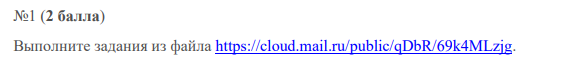

In [2]:
#1
import math
import statistics
import numpy as np
import scipy.stats
import pandas as pd
import seaborn as sns

#2

x = [10.0, 2, 2.5, 5, 26.0]
x_with_nan = [10.0, 2, 2.5, math.nan, 5, 26.0]
print(f'Вывод исходных данных, которые содержатся в x:{x}')
print(f'Вывод исходных данных, которые содержатся в x_with_nan:{x_with_nan}')

#3

y, y_with_nan = np.array(x), np.array(x_with_nan)
z, z_with_nan = pd.Series(x), pd.Series(x_with_nan)
print(f'Вывод данных, которые содержатся в y и y_with_nan:{y}, {y_with_nan}')
print(f'Вывод данных, которые содержатся в z и в z_with_nan: {z}, {z_with_nan}')

#4

#Расчет средних значений
mean_1 = sum(x) / len(x)
print(f'Расчет среднего значения, используя sum и len: {mean_1}')
mean_2 = statistics.mean(x)
print(f'Расчет среднего значения, используя встроенные функции статистики Python (statistics.mean(x)): {mean_2}')
mean_3 = statistics.mean(x)
print(f'Расчет среднего значения, используя встроенные функции статистики Python (statistics.fmean(x)): {mean_3}')
mean_4 = statistics.mean(x_with_nan)
print(f'Расчет среднего значения, который содержит значения nan, используя встроенные функции статистики Python (statistics.mean(x)): {mean_4}')
mean_5 = np.mean(y)
print(f'Расчет среднего значения, используя NumPy: {mean_5}')
np.nanmean(y_with_nan)
print(f'Расчет среднего значения с помощью NumPy, игнорируя nan: {np.nanmean(y_with_nan)}') 
mean_6 = z.mean()
print(f'Расчет среднего значения объекта pd.Series: {mean_6}')

#5

#Расчет средневзвешанных значений
x = [6.0, 1, 2.5, 6, 25.0]
w = [0.1, 0.2, 0.3, 0.25, 0.15]
wmean = sum(w[i] * x[i] for i in range(len(x))) / sum(w)
print(f'Расчет средневзвешанного с помощью range: {wmean}')
wmean2 = sum(x_ * w_ for (x_, w_) in zip(x, w)) / sum(w)
print(f'Расчет средневзвешанного с помощью zip: {wmean2}')
y, z, w = np.array(x), pd.Series(x), np.array(w)
wmean3= np.average(y, weights=w)
print(f'Расчет средневзвешанного с помощью np.average для массивово NumPy или серии Pandas: {wmean3}')
o = (w * y).sum() / w.sum()
print(f'Расчет средневзвешанного с помощью поэлементного умножения w * y: {o}')
w = np.array([0.1, 0.2, 0.3, 0.0, 0.2, 0.1])
print(f'Расчет средневзвешанного для набора, который содержит nan : {(w * y_with_nan).sum() / w.sum()}')

#6

#Гармоническое среднее
hmean = len(x) / sum(1 / item for item in x)
print(f'Расчет гармонического среднего: {hmean}')
hmean2 = statistics.harmonic_mean(x)
print(f'Расчет гармонического среднего с помощью statistics.harmonic_mean(): {hmean2}')
statistics.harmonic_mean(x_with_nan)
print(f'Расчет гармонического среднего, где есть nan: {statistics.harmonic_mean(x_with_nan)}')
statistics.harmonic_mean([1, 0, 2])
print(f'Расчет гармонического среднего, где есть 0: {statistics.harmonic_mean([1, 0, 2])}')
scipy.stats.hmean(y)
print(f'Расчет гармонического среднего с помощью scipy.stats.hmean(): {scipy.stats.hmean(y)}')


#7

#Среднее геометрическое
gmean = 1
for item in x:
    gmean *= item
    gmean **= 1 / len(x)
print(f'Вычисление геометрического среднего: {gmean}')
#gmean2 = statistics.geometric_mean(x)
#print(f'Вычисление геометрического среднего с помощью statistics.geometric_mean(): {gmean2}')
#gmean3 = statistics.geometric_mean(x_with_nan)
#print(f'Вычисление геометрического среднего где есть nan: {gmean3}')
scipy.stats.gmean(y)
print(f'Вычисление геометрического среднего с помощью scipy.stats.gmean(): {scipy.stats.gmean(y)}')

# 8

n = len(x)
if n % 2:
    median_ = sorted(x)[round(0.5*(n-1))]
else:
    x_ord, index = sorted(x), round(0.5 * n)
    median_ = 0.5 * (x_ord[index-1] + x_ord[index])
print(f'Расчет медианы: {median_}')
median_2 = statistics.median(x)
print(f'Расчет медианы с помощью statistics.median(): {median_2}')
statistics.median_low(x[:-1])
print(f'Расчет медианы с помощью statistics.median_low: {statistics.median_low(x[:-1])}')
statistics.median_high(x[:-1])
print(f'Расчет медианы с помощью statistics.median_high {statistics.median_high(x[:-1])}')
median_2 = np.median(y)
print(f'Расчет медианы с помощью np.median: {median_2}')

#9

u = [2, 3, 2, 8, 12]
mode_ = max((u.count(item), item) for item in set(u))[1]
print(f'Вычисление моды: {mode_}')
mode_2 = statistics.mode(u)
print(f'Вычисление моды с помощью statistics.mode(): {mode_2}')
#mode_3 = statistics.multimode(u)
#print(f'Вычисление моды с помощью statistics.multimode(): {mode_3}')
mode_4 = scipy.stats.mode(u)
print(f'Вычисление моды с помощью scipy.stats.mode(): {mode_4}')

#10

n = len(x)
mean = sum(x) / n
var_ = sum((item - mean)**2 for item in x) / (n - 1)
print(f'Оценка дисперсии на чистом Python: {var_}')
var_1= statistics.variance(x)
print(f'Оценка дисперсии с помощью statistics.variance(): {var_1}')
statistics.variance(x_with_nan)
print(f'Оценка дисперсии с помощью statistics.variance(), где есть nan: {statistics.variance(x_with_nan)}')
var_2 = np.var(y, ddof=1)
print(f'Оценка дисперсии, используя NumPy с помощью np.var(): {var_2}')
var_3 = y.var(ddof=1)
print(f'Оценка дисперсии, используя NumPy с помощью метода .var(): {var_3}')

#11

#Среднеквадратичное отклонение
std_ = var_ ** 0.5
print(f'Расчет среднеквадратичного отклонения на чистом Python: {std_}')
std_2 = statistics.stdev(x)
print(f'Расчет среднеквадратичного отклонения с помощью statistics.stdev(): {std_2}')
np.std(y, ddof=1)
print(f'Расчет среднеквадратичного отклонения с помощью NumPy: {np.std(y, ddof=1)}')

#12

#Смещение
x = [8.0, 1, 2.5, 4, 28.0]
n = len(x)
mean_ = sum(x) / n
var_ = sum((item - mean_)**2 for item in x) / (n - 1)
std_ = var_ ** 0.5
skew_ = (sum((item - mean_)**3 for item in x) * n / ((n - 1) * (n - 2) * std_**3))
print(f'Расчет смещения на чистом Python: {skew_}')
z, z_with_nan = pd.Series(x), pd.Series(x_with_nan)
print(f'Расчет смещения с помощью Pandas: {z.skew()}')

#13

#Процентили
x = [-5.0, -1.1, 0.1, 2.0, 8.0, 12.8, 21.0, 25.8, 41.0]
#print(f'Расчет процентилей с помощью statistics.quantiles(): {statistics.quantiles(x, n=2)}')
#statistics.quantiles(x, n=4, method='inclusive')
#print(f"Расчет процентилей с помощью statistics.quantiles(): {statistics.quantiles(x, n=4, method='inclusive')}")
y = np.array(x)
np.percentile(y, 5)
print(f'Нахождение 5 процентиля : {np.percentile(y, 5)}')
np.percentile(y, 95)
print(f'Нахождение 95 процентиля : {np.percentile(y, 95)}')
z, z_with_nan = pd.Series(y), pd.Series(y_with_nan)
z.quantile(0.05)
print(f'Нахождение процентиля используя метод .quantile(): {z.quantile(0.05)}')

#14

#Диапазон
np.ptp(y)
np.ptp(z)
np.ptp(y_with_nan)
np.ptp(z_with_nan)
print(f'Нахождение диапазона с помощью функции np.ptp(): {np.ptp(y),np.ptp(z),np.ptp(y_with_nan),np.ptp(z_with_nan)}')

#15

#Сводка описательной статистики
result = scipy.stats.describe(y, ddof=1, bias=False)
print(f'Сводка описательной статистики с помощью scipy.stats.describe(): {result}')
result2 = z.describe()
print(f'Сводка описательной статистики с помощью метода .describe() в Pandas: {result2}')




Вывод исходных данных, которые содержатся в x:[10.0, 2, 2.5, 5, 26.0]
Вывод исходных данных, которые содержатся в x_with_nan:[10.0, 2, 2.5, nan, 5, 26.0]
Вывод данных, которые содержатся в y и y_with_nan:[10.   2.   2.5  5.  26. ], [10.   2.   2.5  nan  5.  26. ]
Вывод данных, которые содержатся в z и в z_with_nan: 0    10.0
1     2.0
2     2.5
3     5.0
4    26.0
dtype: float64, 0    10.0
1     2.0
2     2.5
3     NaN
4     5.0
5    26.0
dtype: float64
Расчет среднего значения, используя sum и len: 9.1
Расчет среднего значения, используя встроенные функции статистики Python (statistics.mean(x)): 9.1
Расчет среднего значения, используя встроенные функции статистики Python (statistics.fmean(x)): 9.1
Расчет среднего значения, который содержит значения nan, используя встроенные функции статистики Python (statistics.mean(x)): nan
Расчет среднего значения, используя NumPy: 9.1
Расчет среднего значения с помощью NumPy, игнорируя nan: 9.1
Расчет среднего значения объекта pd.Series: 9.1
Расчет

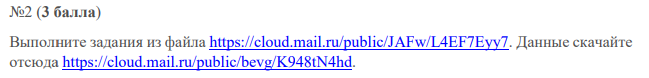

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
# можно и так: import seaborn as sb
from scipy.stats import norm
from scipy import stats
from pandas import DataFrame




In [8]:

#1

pd.set_option('display.max_columns', 100)
df = pd.read_csv('house_train.csv')
df.drop('Id', axis=1, inplace=True)

df.head() # первые пять строк
print(df.shape) #сколько данных в датасете: строки, столбцы
print(df.shape[1]) # Количество параметров (признаков) в датасете
print(df.columns.tolist()) # список всех параметров

categorical_columns = df.select_dtypes(include=['object']).columns.tolist() # категориальные признаки
print(len(categorical_columns)) # их кол-во
print(categorical_columns) # список

df.info(memory_usage='deep')

(1460, 81)
81
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 

In [3]:
#2

print(df.describe()) # Описательная статистика для всех числовых столбцов

print(df.describe().T) # строки и столбцы поменялись(транспонирование)

sale_price_stats = df['SalePrice'].describe()
print(sale_price_stats)

mean_price = df['SalePrice'].mean()
std_price = df['SalePrice'].std()
print(mean_price) # Среднее значение SalePrice
print(std_price) # Стандартное отклонение SalePrice

        MSSubClass  LotFrontage        LotArea  OverallQual  OverallCond  \
count  1460.000000  1201.000000    1460.000000  1460.000000  1460.000000   
mean     56.897260    70.049958   10516.828082     6.099315     5.575342   
std      42.300571    24.284752    9981.264932     1.382997     1.112799   
min      20.000000    21.000000    1300.000000     1.000000     1.000000   
25%      20.000000    59.000000    7553.500000     5.000000     5.000000   
50%      50.000000    69.000000    9478.500000     6.000000     5.000000   
75%      70.000000    80.000000   11601.500000     7.000000     6.000000   
max     190.000000   313.000000  215245.000000    10.000000     9.000000   

         YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1   BsmtFinSF2  \
count  1460.000000   1460.000000  1452.000000  1460.000000  1460.000000   
mean   1971.267808   1984.865753   103.685262   443.639726    46.549315   
std      30.202904     20.645407   181.066207   456.098091   161.319273   
min    1872.000

In [4]:
#3

print(df.duplicated().sum())
duplicated_number=df.duplicated().sum()
print(duplicated_number)

0
0


In [5]:
#4

print(df.columns)

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [ ]:
#5a

na_count = df.isnull().sum().sort_values(ascending=False)
na_rate = na_count / len(df)
na_data = pd.concat([na_count, na_rate],axis=1,keys=['count','ratio'])
print(na_data)


               count     ratio
Unnamed: 81     1460  1.000000
PoolQC          1453  0.995205
MiscFeature     1406  0.963014
Alley           1369  0.937671
Fence           1179  0.807534
...              ...       ...
MiscVal            0  0.000000
YrSold             0  0.000000
SaleType           0  0.000000
SaleCondition      0  0.000000
SalePrice          0  0.000000

[81 rows x 2 columns]


In [12]:
#5b

df_new=df.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1)
df_new = df_new.drop(['GarageQual', 'GarageCond', 'Fence'], axis=1)
df_new=df_new.drop(['MasVnrArea', 'MasVnrType'], axis=1)
print(df_new.isna().sum())
df_new.shape

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 73, dtype: int64


(1460, 73)

In [13]:
#6

df = df_new
df.shape
df = pd.read_csv('house_train.csv')
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Unnamed: 81
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,NaN
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,NaN
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,NaN
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,NaN
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,NaN


Skewness: 1.882876
Kurtosis: 6.536282


C:\Users\lizab\AppData\Local\Temp\ipykernel_11656\1432133209.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'])


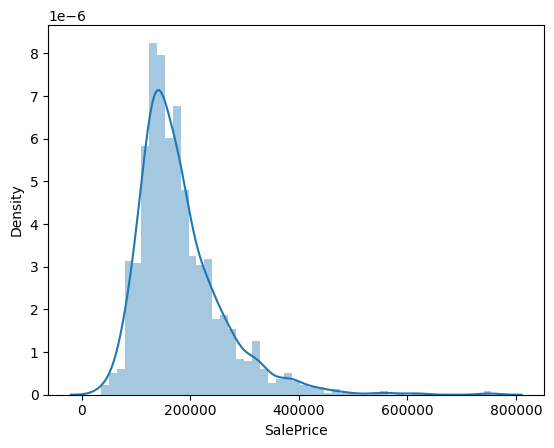

In [ ]:
#6.1

sns.distplot(df['SalePrice'])


In [16]:
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


C:\Users\lizab\AppData\Local\Temp\ipykernel_11656\3975931703.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'], bins=30, kde=False, hist_kws={'color': 'orange','edgecolor': 'darkred', 'linewidth': 1.5, 'alpha': 0.7})


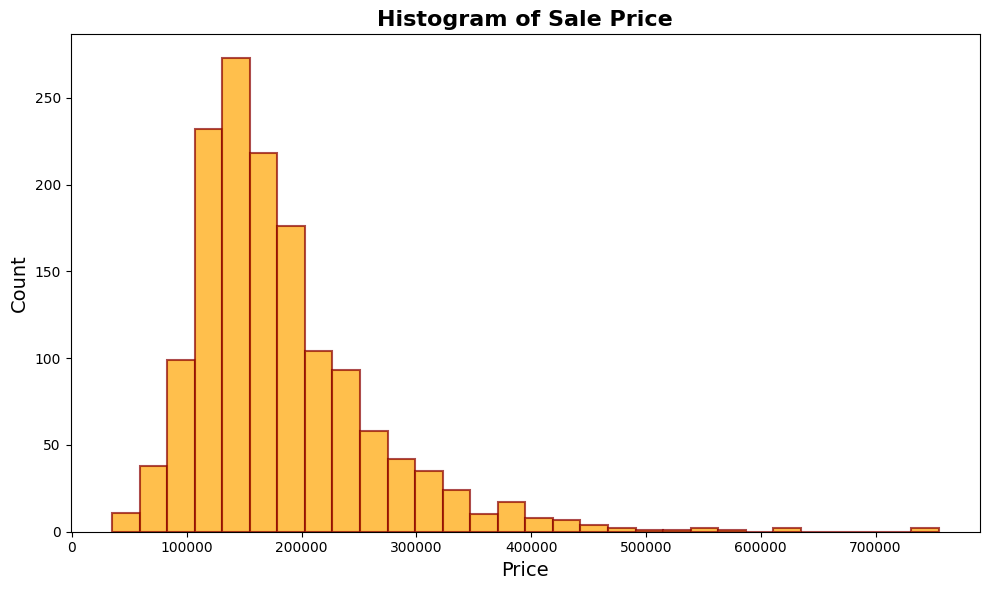

In [21]:
# Задание 6.1

plt.figure(figsize=(10, 6))
sns.distplot(df['SalePrice'], bins=30, kde=False, hist_kws={'color': 'orange','edgecolor': 'darkred', 'linewidth': 1.5, 'alpha': 0.7})

plt.title('Histogram of Sale Price', fontsize=16, fontweight='bold')
plt.xlabel('Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.tight_layout()
plt.show()


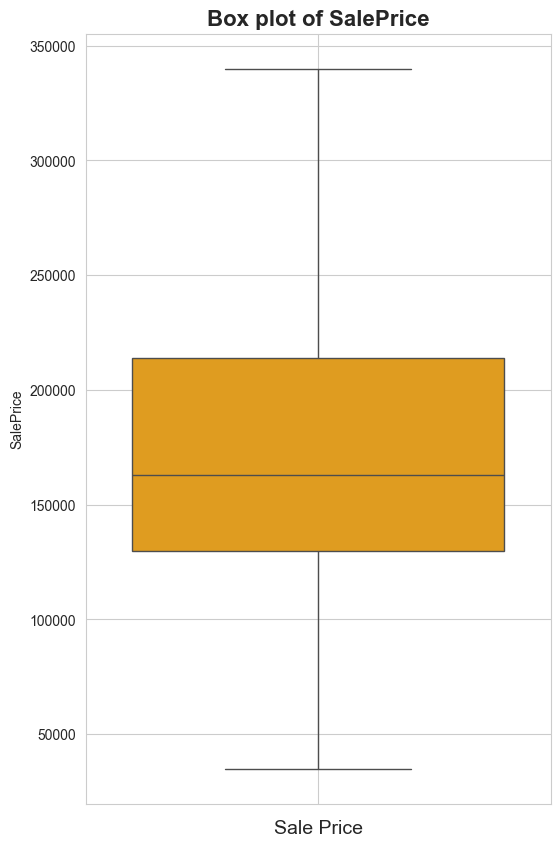

In [ ]:
df = pd.read_csv('house_train.csv')

plt.figure(figsize=(6, 10))
sns.boxplot(y=df['SalePrice'], color='orange', showfliers=False) # послдним параметром убираем выбросы
plt.title('Box plot of SalePrice', fontsize=16, fontweight='bold')
plt.xlabel('Sale Price', fontsize=14)
plt.grid(True)

plt.show()

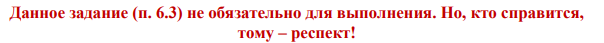

In [ ]:
#6.4
x = df.OverallQual.value_counts()
x/x.sum()

OverallQual
5     0.271918
6     0.256164
7     0.218493
8     0.115068
4     0.079452
9     0.029452
3     0.013699
10    0.012329
2     0.002055
1     0.001370
Name: count, dtype: float64

In [ ]:
#6.4a

x = df.GarageCars.value_counts()
x/x.sum()

# GarageCars 2

GarageCars
2    0.564384
1    0.252740
3    0.123973
0    0.055479
4    0.003425
Name: count, dtype: float64

In [21]:
#6.4b
x = df.CentralAir.value_counts()
x/x.sum()


CentralAir
Y    0.934932
N    0.065068
Name: count, dtype: float64

In [23]:
#6.5

df.SalePrice.describe()
print('The proportion of the houses with prices between 25th percentile and 75th percentile: ', np.mean((df.SalePrice >= 129975) & (df.SalePrice <= 214000)))

print('The proportion of house with total square feet of basement area between 25th percentile and 75th percentile: ', np.mean((df.TotalBsmtSF >= 795.75) & (df.TotalBsmtSF <= 1298.25)))

a = (df.SalePrice >= 129975) & (df.SalePrice <= 214000) 
b = (df.TotalBsmtSF >= 795.75) & (df.TotalBsmtSF <= 1298.25)
print(np.mean(a | b))

q75, q25 = np.percentile(df.loc[df['CentralAir']=='N']['SalePrice'], [75,25])
iqr = q75 - q25
print('Sale price IQR for houses with no air conditioning: ', iqr)


q75, q25 = np.percentile(df.loc[df['CentralAir']=='Y']['SalePrice'], [75,25])
iqr = q75 - q25
print('Sale price IQR for houses with air conditioning: ', iqr)



The proportion of the houses with prices between 25th percentile and 75th percentile:  0.5020547945205479
The proportion of house with total square feet of basement area between 25th percentile and 75th percentile:  0.5
0.7143835616438357
Sale price IQR for houses with no air conditioning:  46500.0
Sale price IQR for houses with air conditioning:  84410.0


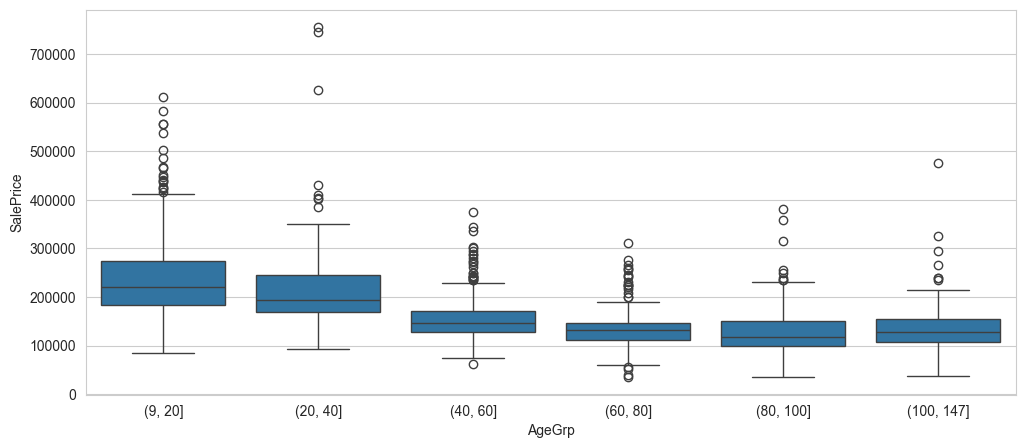

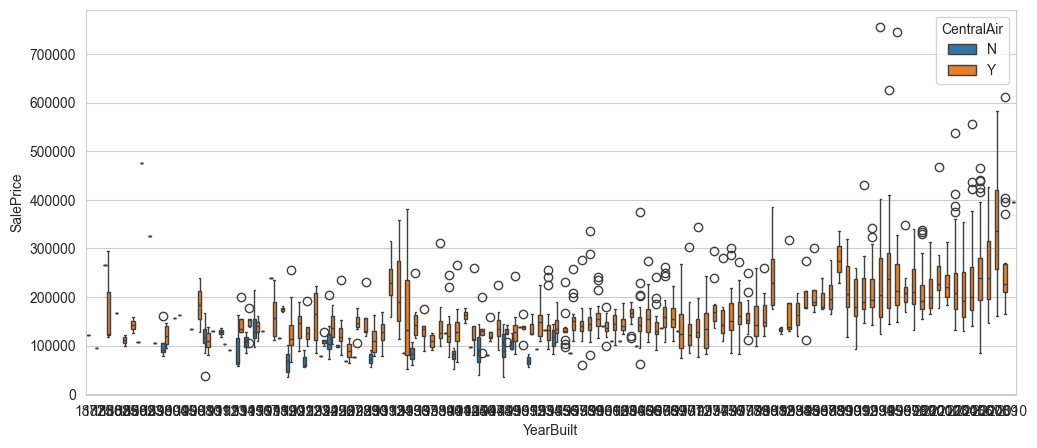

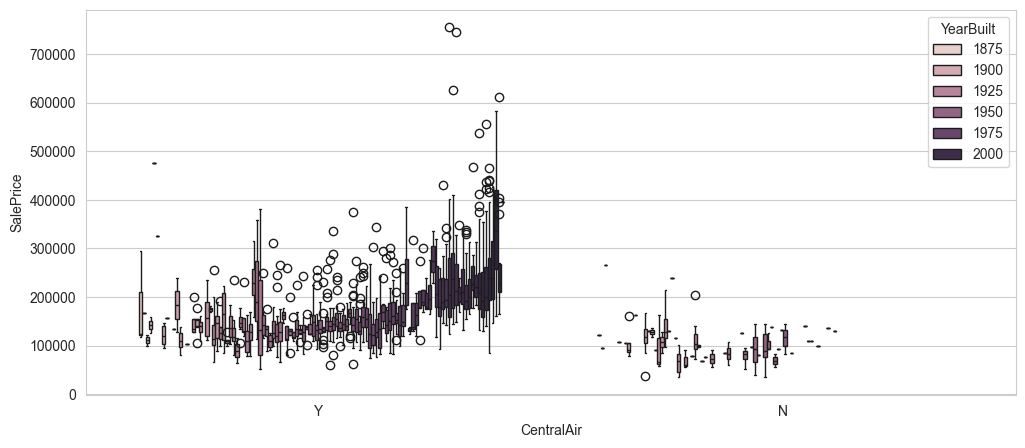

BldgType              1Fam  2fmCon  Duplex  Twnhs  TwnhsE
YearBuilt CentralAir                                     
1872      N          1.000     NaN     NaN    NaN     NaN
1875      N          1.000     NaN     NaN    NaN     NaN
1880      N          1.000     NaN     NaN    NaN     NaN
          Y          1.000     NaN     NaN    NaN     NaN
1882      Y          1.000     NaN     NaN    NaN     NaN
1885      Y          0.500   0.500     NaN    NaN     NaN
1890      Y          1.000     NaN     NaN    NaN     NaN
1892      N          1.000     NaN     NaN    NaN     NaN
          Y          1.000     NaN     NaN    NaN     NaN
1893      Y          1.000     NaN     NaN    NaN     NaN
1898      N          1.000     NaN     NaN    NaN     NaN
1900      N          0.400   0.600     NaN    NaN     NaN
          Y          0.400   0.400   0.200    NaN     NaN
1904      Y          1.000     NaN     NaN    NaN     NaN
1905      N            NaN   1.000     NaN    NaN     NaN
1906      Y   

In [ ]:
#6.6

df['HouseAge'] = 2019 - df['YearBuilt']
df["AgeGrp"] = pd.cut(df.HouseAge, [9, 20, 40, 60, 80, 100, 147]) # Create age strata based on these cut points
plt.figure(figsize=(12, 5))
sns.boxplot(x="AgeGrp", y="SalePrice", data=df) # Чем новее дом, тем выше его средняя цена

plt.figure(figsize=(12, 5))
sns.boxplot(x="YearBuilt", y="SalePrice", hue="CentralAir", data=df)
plt.show() # Кондиционеры в более старых домах отсутсвуют

plt.figure(figsize=(12, 5))
sns.boxplot(x="CentralAir", y="SalePrice", hue="YearBuilt", data=df)
plt.show()

df1 = df.groupby(["YearBuilt", "CentralAir"])["BldgType"]
df1 = df1.value_counts()
df1 = df1.unstack()
df1 = df1.apply(lambda x: x/x.sum(), axis=1)
print(df1.to_string(float_format="%.3f"))


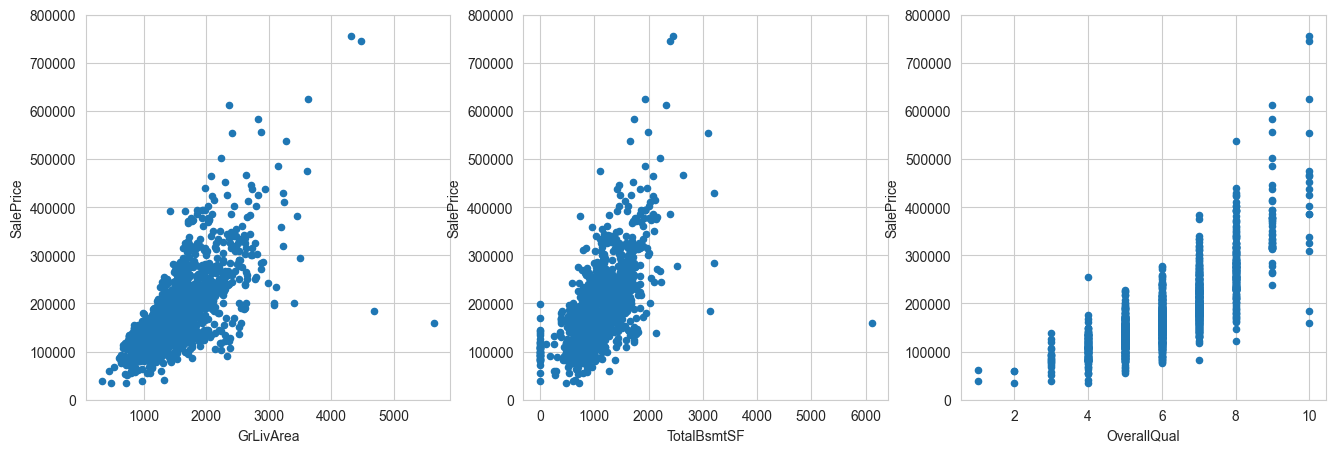

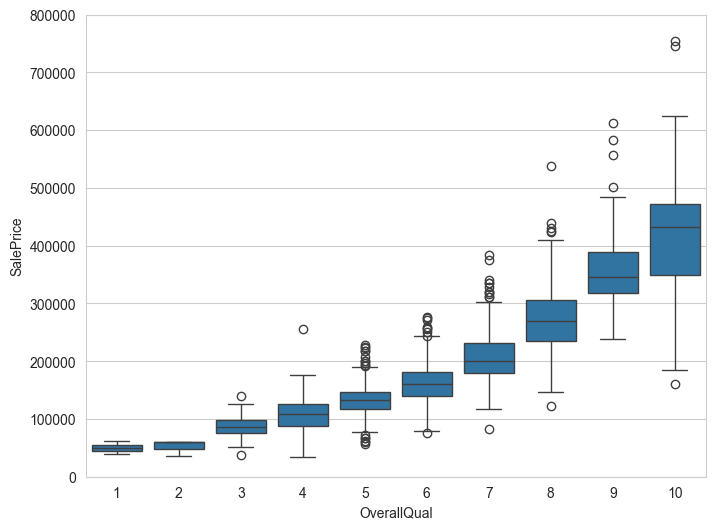

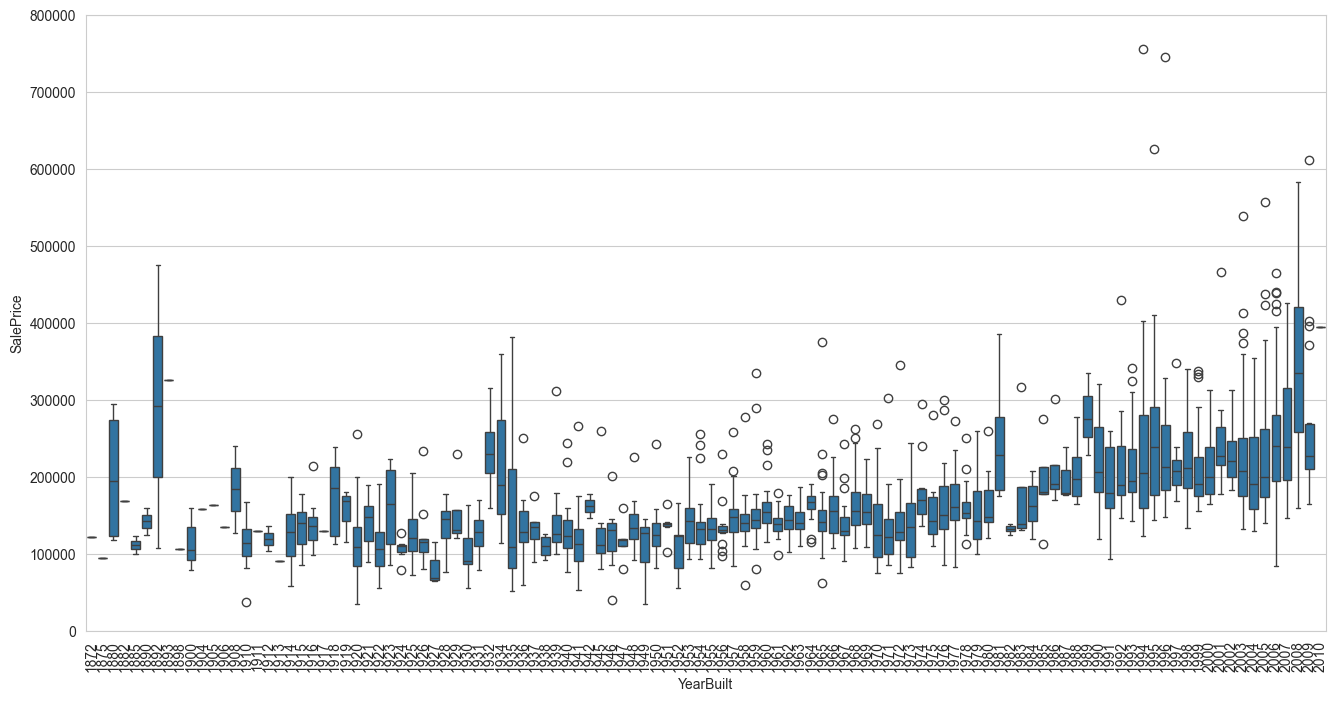

In [26]:
#6.6

output,var,var1,var2 = 'SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual' 
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(16,5))
df.plot.scatter(x=var,y=output,ylim=(0,800000),ax=axes[0])
df.plot.scatter(x=var1,y=output,ylim=(0,800000),ax=axes[1])
df.plot.scatter(x=var2,y=output,ylim=(0,800000),ax=axes[2])

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(x=var2,y=output,data=df)
ax.set_ylim(0,800000)
plt.show()

var3 = 'YearBuilt'
fig, ax = plt.subplots(figsize=(16,8))
sns.boxplot(x=var3,y=output,data=df)
ax.set_ylim(0,800000)
plt.xticks(rotation=90)
plt.show()


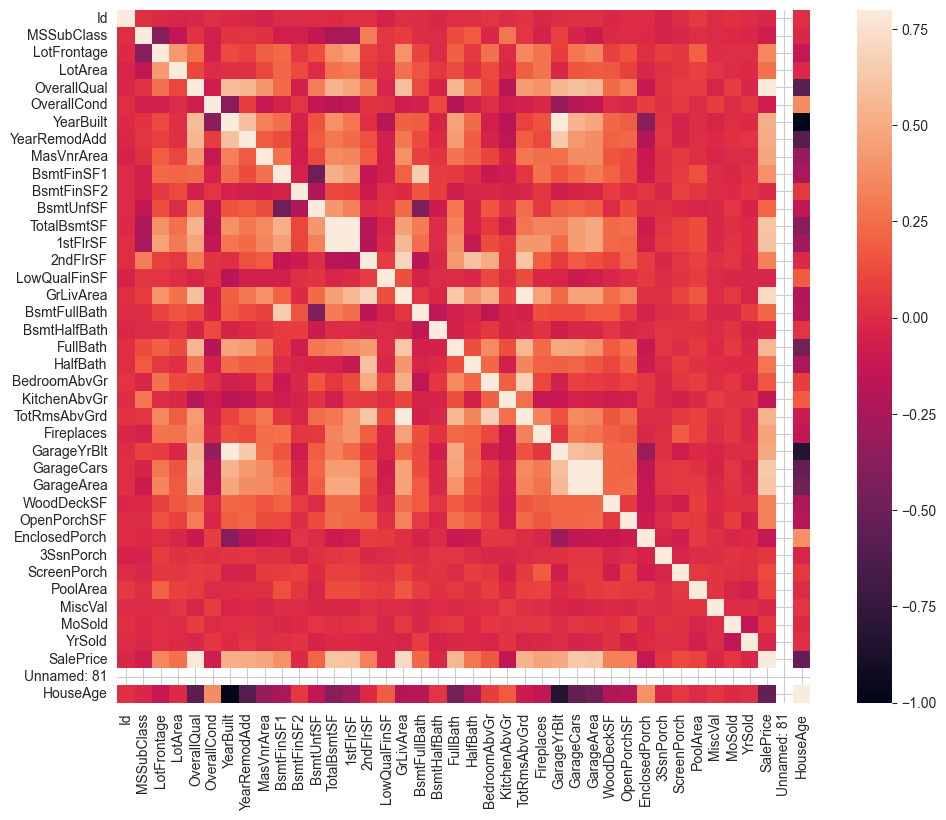

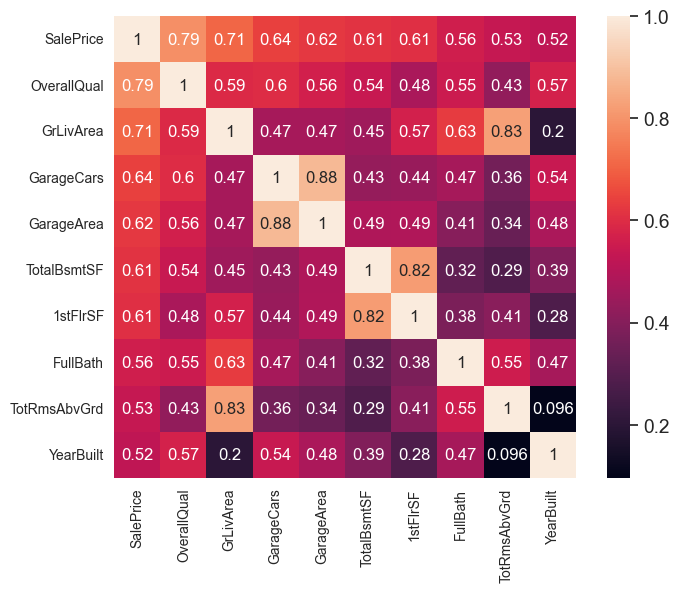

In [29]:
#6.7

numeric_df = df.select_dtypes(include=[np.number])
corrmat = numeric_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap (corrmat, vmax = .8, square = True, ax = ax) #Параметр square гарантирует, что когда corrmat -неквадратная матрица, общий вывод графика по-прежнему будет квадратным
plt.show()

k = 10
top10_attr = corrmat.nlargest(k, output).index
top10_mat = corrmat.loc[top10_attr, top10_attr]
fig,ax = plt.subplots(figsize=(8,6))
sns.set(font_scale=1.25)
sns.heatmap(top10_mat, annot=True, annot_kws={'size':12},
square=True)
# Установите аннотацию для отображения чисел в маленьких ячейках и annot_kws для настройки числового формата
plt.show()


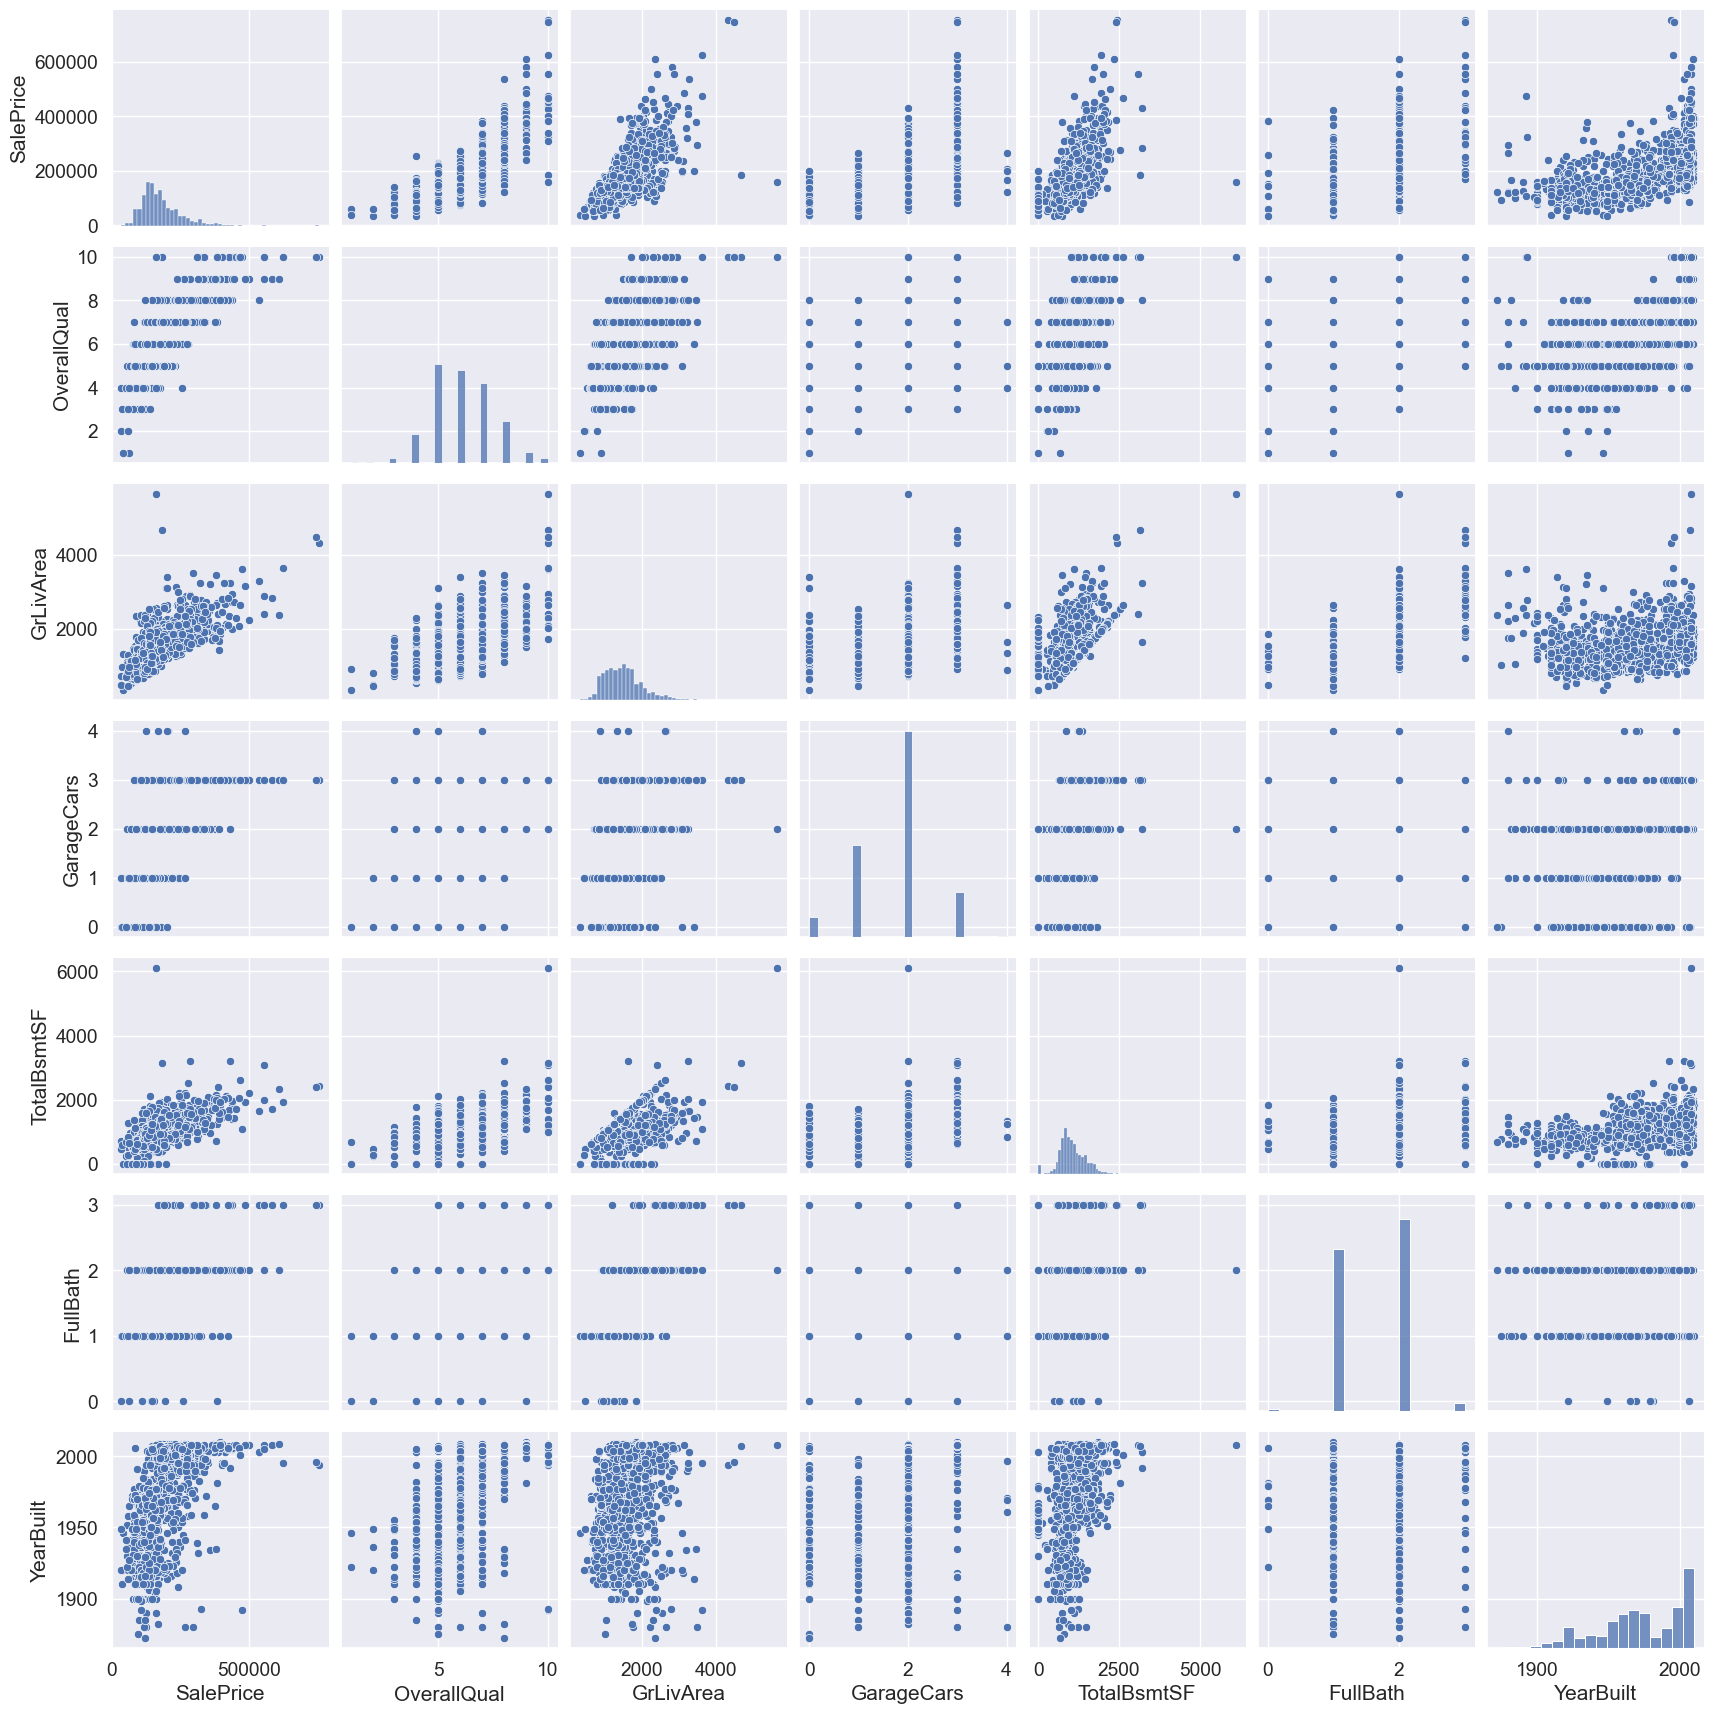

In [30]:
#6.7

var_set = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.set (font_scale = 1.25) # Устанавливаем размер шрифта по горизонтальной и вертикальной оси
sns.pairplot (df[var_set]) # 7 * 7 графическая матрица
# Различные типы отображения могут быть установлены в параметрах kind и diag_kind, вот диаграммы разброса и гистограммы, и вы также можете установить разные типы отображения на каждом графике
plt.show()

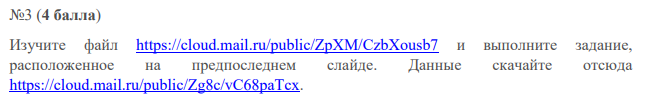

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('water.txt', sep='\t')
df.columns = ['location', 'town', 'mortality', 'hardness']

# 1) Описательные статистики для северных и южных городов
north = df[df['location'] == 'Nort']
south = df[df['location'] == 'Sout']

print("Описательные статистики для северных городов:")
print(north[['mortality', 'hardness']].describe())
print("\nОписательные статистики для южных городов:")
print(south[['mortality', 'hardness']].describe())

print("\nСредняя смертность:")
print(f"Север: {north['mortality'].mean():.2f}")
print(f"Юг: {south['mortality'].mean():.2f}")

print("\nСредняя жёсткость воды:")
print(f"Север: {north['hardness'].mean():.2f}")
print(f"Юг: {south['hardness'].mean():.2f}")

# 2) 95% доверительные интервалы для смертности
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean - h, mean + h

ci_north_mort = confidence_interval(north['mortality'])
ci_south_mort = confidence_interval(south['mortality'])

print("\n95% ДИ для смертности:")
print(f"Север: ({ci_north_mort[0]:.2f}, {ci_north_mort[1]:.2f})")
print(f"Юг: ({ci_south_mort[0]:.2f}, {ci_south_mort[1]:.2f})")

# 3) 95% доверительные интервалы для жёсткости воды
ci_north_hard = confidence_interval(north['hardness'])
ci_south_hard = confidence_interval(south['hardness'])

print("\n95% ДИ для жёсткости воды:")
print(f"Север: ({ci_north_hard[0]:.2f}, {ci_north_hard[1]:.2f})")
print(f"Юг: ({ci_south_hard[0]:.2f}, {ci_south_hard[1]:.2f})")

Описательные статистики для северных городов:
        mortality   hardness
count   35.000000  35.000000
mean   162.857143  30.400000
std     13.760863  26.134494
min    137.000000   6.000000
25%    155.000000  12.500000
50%    163.000000  17.000000
75%    171.500000  44.000000
max    198.000000  94.000000

Описательные статистики для южных городов:
        mortality    hardness
count   26.000000   26.000000
mean   137.076923   69.769231
std     14.053962   40.360682
min    109.000000    5.000000
25%    125.250000   40.250000
50%    135.500000   75.500000
75%    148.000000   99.750000
max    162.000000  138.000000

Средняя смертность:
Север: 162.86
Юг: 137.08

Средняя жёсткость воды:
Север: 30.40
Юг: 69.77

95% ДИ для смертности:
Север: (158.13, 167.58)
Юг: (131.40, 142.75)

95% ДИ для жёсткости воды:
Север: (21.42, 39.38)
Юг: (53.47, 86.07)


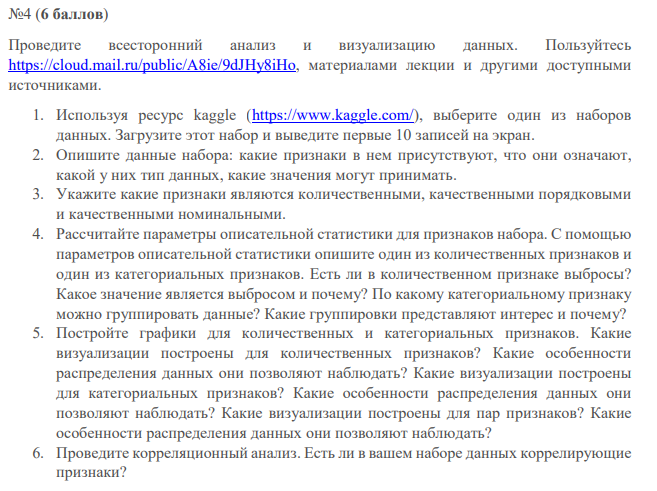

In [ ]:
#1

df = pd.read_csv('StudentPerformance.csv')
print(df.head(10))

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   
5              3               78                         No            9   
6              7               73                        Yes            5   
7              8               45                        Yes            4   
8              5               77                         No            8   
9              4               89                         No            4   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2   

In [42]:
#2

print(df.shape) #сколько данных в датасете: строки, столбцы
print(df.shape[1]) # Количество параметров (признаков) в датасете
print(df.columns.tolist()) # список всех параметров

categorical_columns = df.select_dtypes(include=['object']).columns.tolist() # категориальные признаки
print(len(categorical_columns)) # их кол-во
print(categorical_columns) # список

df.info(memory_usage='deep')

print("\nТипы данных каждого признака:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

print("\nКатегориальный признак может принимать значения:")
for col in categorical_columns:
    print(f"{col}: {df[col].unique().tolist()}")

print("\nЧисловые признаки (диапазоны):")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    print(f"{col}: от {df[col].min()} до {df[col].max()}")

(10000, 6)
6
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
1
['Extracurricular Activities']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 893.6 KB

Типы данных каждого признака:
Hours Studied: int64
Previous Scores: int64
Extracurricular Activities: object
Sleep Hours: int64
Sample Quest

In [ ]:
#3

#Hours Studied (Часы учебы) – количественный (дискретный, целочисленный)

#Previous Scores (Предыдущие баллы) – количественный (непрерывный или дискретный, целочисленный)

#Extracurricular Activities (Внеклассные активности) – качественный номинальный (бинарный: Yes/No, без порядка)

#Sleep Hours (Часы сна) – количественный (дискретный, целочисленный)

#Sample Question Papers Practiced (Решённые пробные тесты) – количественный (дискретный, целочисленный)

#Performance Index (Показатель успеваемости) – количественный (непрерывный, дробный)

In [ ]:
#4

quantitative_stats = df.describe()
print(quantitative_stats)
categorical_stats = df.describe(include=['object'])
print(categorical_stats)

prev_scores = df['Previous Scores']
print(f"Среднее значение: {prev_scores.mean():.2f}")
print(f"Медиана: {prev_scores.median():.2f}")
print(f"Стандартное отклонение: {prev_scores.std():.2f}")
print(f"Минимум: {prev_scores.min()}")
print(f"Максимум: {prev_scores.max()}")

extracurricular = df['Extracurricular Activities']
print(f"Количество уникальных значений: {extracurricular.nunique()}")
print(f"Уникальные значения: {extracurricular.unique()}")
print(f"Частотное распределение:")
print(extracurricular.value_counts())
print(f"Мода (наиболее частое значение): {extracurricular.mode()[0]}")

Q1 = prev_scores.quantile(0.25)
Q3 = prev_scores.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = prev_scores[(prev_scores < lower_bound) | (prev_scores > upper_bound)]
print(f"Выбросы по IQR методу: {len(outliers_iqr)} шт.")
print(f"Значения: {outliers_iqr.tolist()}")


grouped = df.groupby('Extracurricular Activities')
print("\nГруппировка по 'Extracurricular Activities':")
print(f"Количество групп: {len(grouped)}")
print("Размеры групп:")
print(grouped.size())
mean_performance = grouped['Performance Index'].mean()
print(mean_performance)
# группировка для студентов по внеклассным мероприятим
# студенты которые занимаются внеклассным мероприятим учатся примерно на один процент лучше
mean_hours = grouped['Sleep Hours'].mean()
print(mean_hours)
# студенты которые занимаются внеклассным мероприятим спят немного хуже, но это не значительно

       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

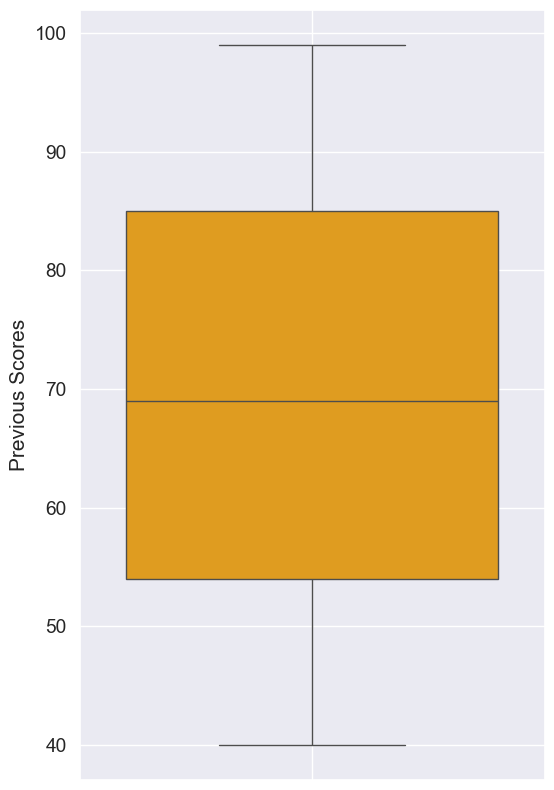

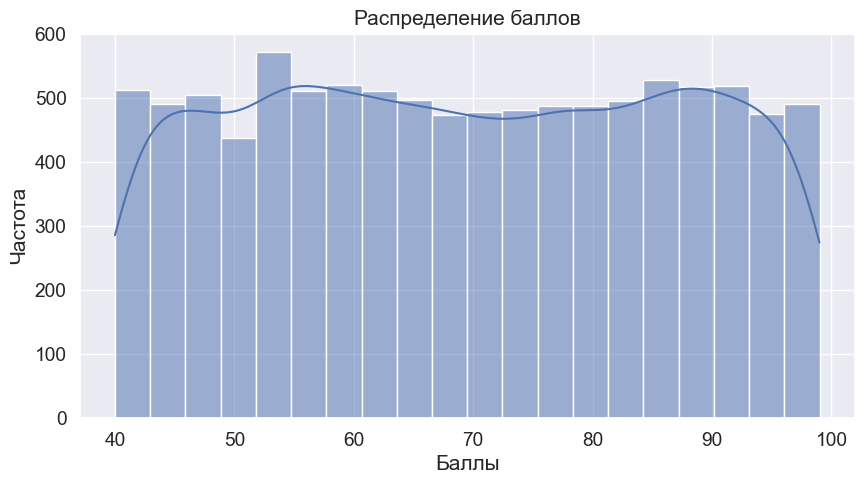

C:\Users\lizab\AppData\Local\Temp\ipykernel_7808\69915229.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Extracurricular Activities', data=df,


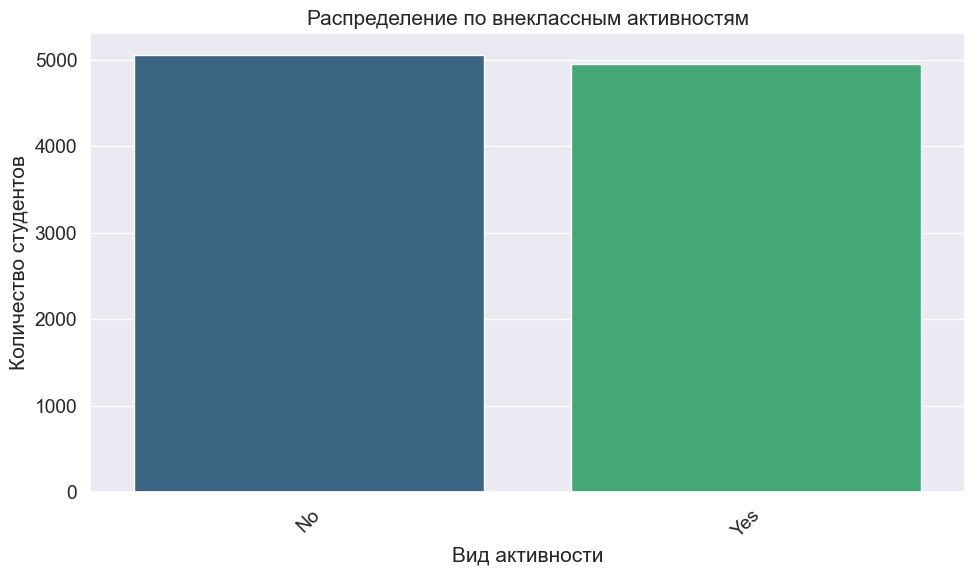

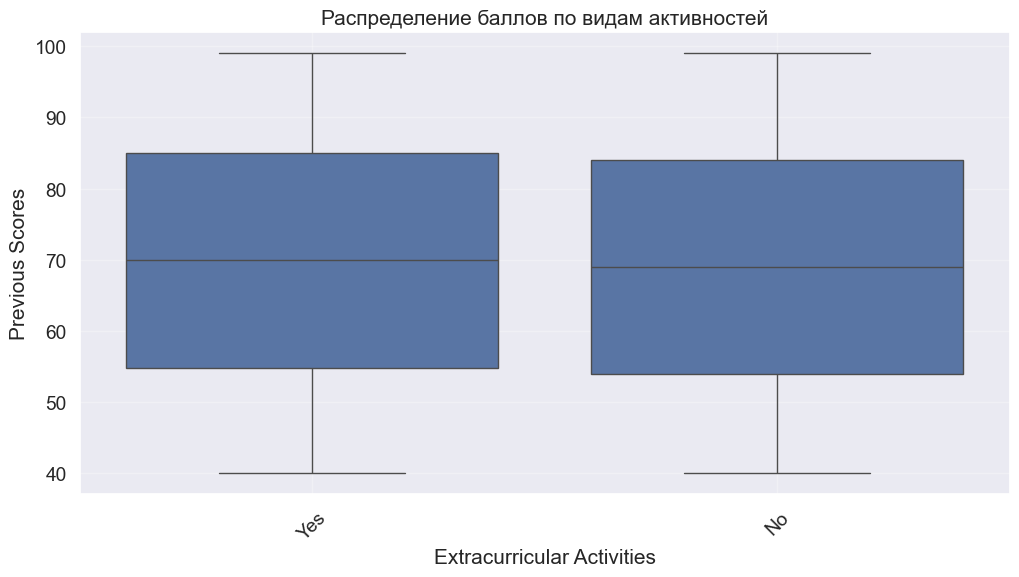

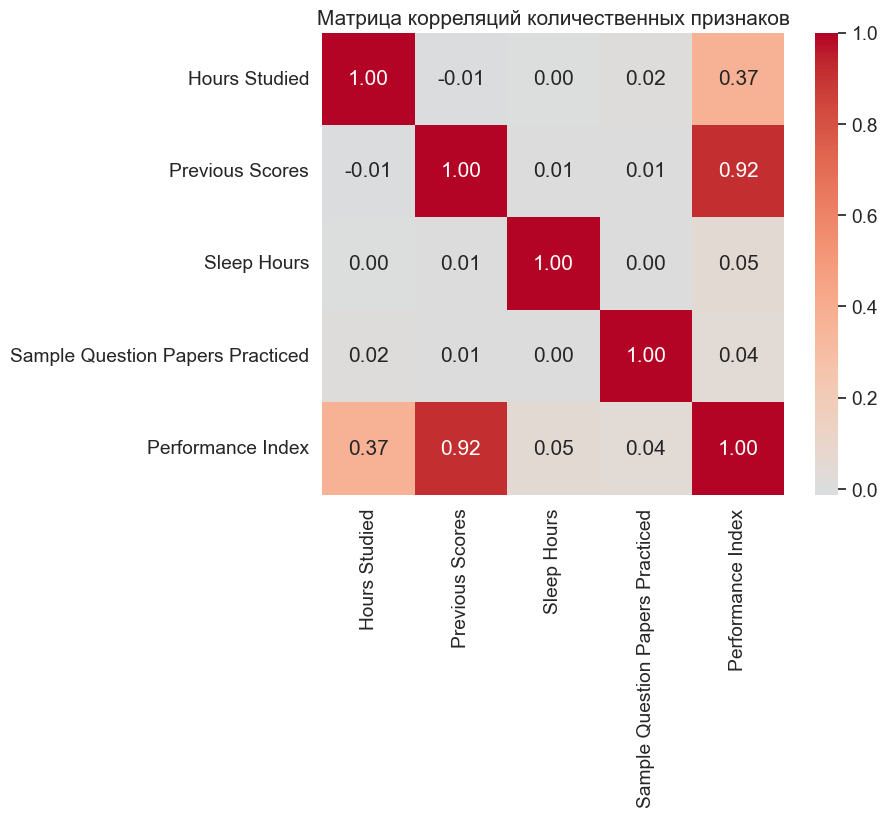

In [67]:
#5

plt.figure(figsize=(6, 10))
sns.boxplot(y=df['Previous Scores'], color='orange') 
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['Previous Scores'], kde=True, bins=20)
plt.title('Распределение баллов')
plt.xlabel('Баллы')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Extracurricular Activities', data=df, 
                   order=df['Extracurricular Activities'].value_counts().index,
                   palette='viridis')
plt.title('Распределение по внеклассным активностям')
plt.xlabel('Вид активности')
plt.ylabel('Количество студентов')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Extracurricular Activities', y='Previous Scores', data=df)
plt.title('Распределение баллов по видам активностей')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True)
plt.title('Матрица корреляций количественных признаков')
plt.show()

In [ ]:
#6

corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

print("Корреляционная матрица:")
print(corr_matrix.round(2))

# Все признаки статистически независимы друг от друга. Это означает, что каждый признак вносит уникальную информацию в модель.

Корреляционная матрица:
                                  Hours Studied  Previous Scores  Sleep Hours  \
Hours Studied                              1.00            -0.01         0.00   
Previous Scores                           -0.01             1.00         0.01   
Sleep Hours                                0.00             0.01         1.00   
Sample Question Papers Practiced           0.02             0.01         0.00   
Performance Index                          0.37             0.92         0.05   

                                  Sample Question Papers Practiced  \
Hours Studied                                                 0.02   
Previous Scores                                               0.01   
Sleep Hours                                                   0.00   
Sample Question Papers Practiced                              1.00   
Performance Index                                             0.04   

                                  Performance Index  
Hours Studied 